# Gene-activity vs. Xenium expression loss evaluation

Compares 4 MOSAICField alignment x assignment conditions:
- **affine + Method A** (nearest-neighbor, 20um cutoff)
- **affine + Method B** (Voronoi, 30um soft filter)
- **nonlinear + Method A**
- **nonlinear + Method B**

Loss = agreement between ArchR `GeneScoreMatrix` gene activity (488B deepseq, 5000bp tiles, log1p)
and pseudobulk Xenium log-normalized expression of cells assigned to each ATAC spot, computed only
on the genes shared between the ArchR GeneScoreMatrix and the Xenium panel.

Inputs (all already produced upstream):
- `mosaicfield_outputs/gene_loss_inputs/` — exported by `export_genescore_for_loss.R`
- `mosaicfield_outputs/r_comparison/` — mapping CSVs + `atac_coords.csv` from `export_for_R.py`
- `mosaicfield_outputs/xenium_affine_aligned.h5ad` — log-normalized Xenium expression


In [1]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.io import mmread
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

outdir = "./mosaicfield_outputs"
gli_dir = os.path.join(outdir, "gene_loss_inputs_v2")  # v2: corrected ArchR project, 11,319 cells
rcmp_dir = os.path.join(outdir, "r_comparison")

sns.set_style("whitegrid")


## 1. Load ArchR gene activity (GeneScoreMatrix, shared genes, log1p)

In [2]:
gene_names = pd.read_csv(os.path.join(gli_dir, "archr_gene_names.csv"))["gene"].tolist()
archr_barcodes = pd.read_csv(os.path.join(gli_dir, "archr_barcodes.csv"))["barcode"].tolist()

gs_mat = mmread(os.path.join(gli_dir, "archr_genescore_shared.mtx")).tocsr()  # genes x cells
assert gs_mat.shape == (len(gene_names), len(archr_barcodes))

gene_activity_log = np.log1p(gs_mat.toarray()).T  # cells x genes
gene_activity_df = pd.DataFrame(gene_activity_log, index=archr_barcodes, columns=gene_names)
gene_activity_df.index.name = "barcode"

print(f"ArchR gene activity: {gene_activity_df.shape[0]} spots x {gene_activity_df.shape[1]} genes")


ArchR gene activity: 11319 spots x 377 genes


## 2. Load spot coordinates (affine + nonlinear) and join to ArchR barcodes

In [3]:
atac_coords = pd.read_csv(os.path.join(rcmp_dir, "atac_coords.csv"))
atac_coords["barcode"] = atac_coords["spot_id"].str.split("#").str[-1]

spots = atac_coords.merge(gene_activity_df, on="barcode", how="inner")
spots = spots.set_index("spot_idx", drop=False)

print(f"Spots with both coordinates and ArchR gene activity: {spots.shape[0]} "
      f"(out of {atac_coords.shape[0]} total ATAC spots in the alignment)")

gene_activity_by_idx = spots.set_index("spot_idx")[gene_names]
coords_by_idx = spots.set_index("spot_idx")[["affine_x", "affine_y", "nonlinear_x", "nonlinear_y"]]


Spots with both coordinates and ArchR gene activity: 11319 (out of 11640 total ATAC spots in the alignment)


## 3. Load Xenium log-normalized expression, subset to shared genes

In [4]:
xenium = ad.read_h5ad(os.path.join(outdir, "xenium_affine_aligned.h5ad"))

xenium_genes_shared = [g for g in gene_names if g in xenium.var_names]
print(f"Shared genes present in BOTH ArchR GeneScoreMatrix and the Xenium h5ad: "
      f"{len(xenium_genes_shared)} / {len(gene_names)}")

xenium_expr = pd.DataFrame(
    xenium[:, xenium_genes_shared].X.toarray(),
    index=xenium.obs_names,
    columns=xenium_genes_shared,
)
xenium_expr.index.name = "xenium_cell"

# Restrict everything downstream to this final shared-gene list
shared_genes = xenium_genes_shared
gene_activity_by_idx = gene_activity_by_idx[shared_genes]

print(f"Final shared gene space used for scoring: {len(shared_genes)} genes")


Shared genes present in BOTH ArchR GeneScoreMatrix and the Xenium h5ad: 377 / 377


Final shared gene space used for scoring: 377 genes


## 4. Load the 4 alignment x assignment mapping conditions

In [5]:
mapping_files = {
    "affine_methodA":    ("mapping_affine_nn.csv",       "assigned", True),
    "affine_methodB":     ("mapping_affine_voronoi.csv",  "distant",  False),
    "nonlinear_methodA": ("mapping_nonlinear_nn.csv",    "assigned", True),
    "nonlinear_methodB":  ("mapping_nonlinear_voronoi.csv","distant",  False),
}

mappings = {}
for name, (fname, flag_col, keep_value) in mapping_files.items():
    m = pd.read_csv(os.path.join(rcmp_dir, fname))
    m = m[m[flag_col] == keep_value].copy()
    mappings[name] = m
    print(f"{name:20s}: {m.shape[0]:6d} confidently-assigned cells "
          f"(from {pd.read_csv(os.path.join(rcmp_dir, fname)).shape[0]} total)")


affine_methodA      :  54826 confidently-assigned cells (from 60593 total)


affine_methodB      :  55582 confidently-assigned cells (from 60593 total)


nonlinear_methodA   :  55330 confidently-assigned cells (from 60593 total)


nonlinear_methodB   :  60397 confidently-assigned cells (from 60593 total)


## 5. Loss function

For a given assignment, build the pseudobulk Xenium profile per ATAC spot (mean log-expression
across confidently-assigned cells), join to the ArchR gene activity for that spot, and score
agreement on the shared gene space both per-gene (across spots) and per-spot (across genes).


In [6]:
def compute_loss(mapping_df, gene_activity_by_idx, xenium_expr, shared_genes):
    """Returns dict with per-gene df, per-spot df, and summary scalars."""
    m = mapping_df.merge(xenium_expr[shared_genes], left_on="xenium_cell", right_index=True, how="inner")
    pseudobulk = m.groupby("atac_spot_idx")[shared_genes].mean()

    common_idx = pseudobulk.index.intersection(gene_activity_by_idx.index)
    pseudobulk = pseudobulk.loc[common_idx]
    activity = gene_activity_by_idx.loc[common_idx]

    n_spots = len(common_idx)
    if n_spots < 3:
        raise ValueError("Too few spots with both gene activity and assigned cells.")

    # Per-gene correlation (across spots) -- "for all the gene points"
    gene_rows = []
    for g in shared_genes:
        x = activity[g].values
        y = pseudobulk[g].values
        if np.std(x) == 0 or np.std(y) == 0:
            pear, spear = np.nan, np.nan
        else:
            pear, _ = pearsonr(x, y)
            spear, _ = spearmanr(x, y)
        gene_rows.append((g, pear, spear))
    per_gene = pd.DataFrame(gene_rows, columns=["gene", "pearson", "spearman"]).dropna()

    # Per-spot correlation (across genes) -- spatial diagnostic
    spot_rows = []
    for idx in common_idx:
        x = activity.loc[idx].values
        y = pseudobulk.loc[idx].values
        if np.std(x) == 0 or np.std(y) == 0:
            pear, cos = np.nan, np.nan
        else:
            pear, _ = pearsonr(x, y)
            cos = cosine_similarity(x.reshape(1, -1), y.reshape(1, -1))[0, 0]
        spot_rows.append((idx, pear, cos))
    per_spot = pd.DataFrame(spot_rows, columns=["atac_spot_idx", "pearson", "cosine"]).dropna()

    summary = {
        "n_spots": n_spots,
        "median_gene_pearson": per_gene["pearson"].median(),
        "median_gene_spearman": per_gene["spearman"].median(),
        "global_pearson": pearsonr(activity.values.ravel(), pseudobulk.values.ravel())[0],
        "median_spot_pearson": per_spot["pearson"].median(),
    }
    return {"per_gene": per_gene, "per_spot": per_spot, "summary": summary}


## 6. Run the loss function on the 4 baseline conditions

In [7]:
results = {}
for name in mapping_files:
    results[name] = compute_loss(mappings[name], gene_activity_by_idx, xenium_expr, shared_genes)

summary_table = pd.DataFrame({name: r["summary"] for name, r in results.items()}).T
summary_table.index.name = "condition"
summary_table


,n_spots,median_gene_pearson,median_gene_spearman,global_pearson,median_spot_pearson
condition,,,,,
affine_methodA,11030.0,0.010722,0.011962,0.129128,0.128091
affine_methodB,11033.0,0.011094,0.011761,0.129291,0.128164
nonlinear_methodA,11162.0,0.016238,0.016488,0.137931,0.137968
nonlinear_methodB,11181.0,0.016559,0.016338,0.138891,0.138798


In [8]:
per_gene_long = pd.concat(
    [r["per_gene"].assign(condition=name) for name, r in results.items()],
    ignore_index=True,
)
per_spot_long = pd.concat(
    [r["per_spot"].assign(condition=name) for name, r in results.items()],
    ignore_index=True,
)
per_gene_long.head()


,gene,pearson,spearman,condition
0,MTOR,0.017245,0.016776,affine_methodA
1,C1QA,0.006622,0.005388,affine_methodA
2,C1QC,0.004269,0.000465,affine_methodA
3,TRAPPC3,-0.001379,0.002089,affine_methodA
4,SMAP2,0.027553,0.026692,affine_methodA


## 7. Multi-resolution sweep

Bin ATAC spots into square spatial grid cells of increasing size (in um), aggregating gene
activity (sum) and re-pooling assigned Xenium cells per bin, then rescoring.


In [9]:
def assign_grid_bin(x, y, bin_size):
    return (np.floor(x / bin_size).astype(int).astype(str) + "_" +
            np.floor(y / bin_size).astype(int).astype(str))

def compute_loss_at_resolution(mapping_df, gene_activity_by_idx, coords_by_idx,
                                xenium_expr, shared_genes, bin_size, coord_cols):
    xcol, ycol = coord_cols
    bins = assign_grid_bin(coords_by_idx[xcol].values, coords_by_idx[ycol].values, bin_size)
    spot_to_bin = pd.Series(bins, index=coords_by_idx.index, name="bin_id")

    activity_binned = gene_activity_by_idx.groupby(spot_to_bin).sum()

    m = mapping_df.merge(xenium_expr[shared_genes], left_on="xenium_cell", right_index=True, how="inner")
    m = m.merge(spot_to_bin.rename("bin_id"), left_on="atac_spot_idx", right_index=True, how="inner")
    pseudobulk_binned = m.groupby("bin_id")[shared_genes].mean()

    common_bins = activity_binned.index.intersection(pseudobulk_binned.index)
    activity_binned = activity_binned.loc[common_bins]
    pseudobulk_binned = pseudobulk_binned.loc[common_bins]

    if len(common_bins) < 3:
        return {"n_bins": len(common_bins), "mean_gene_pearson": np.nan,
                "median_gene_pearson": np.nan, "global_pearson": np.nan}

    pears = []
    for g in shared_genes:
        x, y = activity_binned[g].values, pseudobulk_binned[g].values
        if np.std(x) > 0 and np.std(y) > 0:
            pears.append(pearsonr(x, y)[0])
    return {
        "n_bins": len(common_bins),
        "mean_gene_pearson": np.nanmean(pears) if pears else np.nan,
        "median_gene_pearson": np.nanmedian(pears) if pears else np.nan,
        "global_pearson": pearsonr(activity_binned.values.ravel(), pseudobulk_binned.values.ravel())[0],
    }

resolutions_um = [0, 25, 50, 100, 200, 400]  # 0 = native spot resolution
coord_cols_for = {
    "affine_methodA": ("affine_x", "affine_y"),
    "affine_methodB": ("affine_x", "affine_y"),
    "nonlinear_methodA": ("nonlinear_x", "nonlinear_y"),
    "nonlinear_methodB": ("nonlinear_x", "nonlinear_y"),
}

resolution_rows = []
for name in mapping_files:
    for res in resolutions_um:
        if res == 0:
            s = results[name]["summary"]
            row = {"n_bins": s["n_spots"],
                   "mean_gene_pearson": results[name]["per_gene"]["pearson"].mean(),
                   "median_gene_pearson": s["median_gene_pearson"],
                   "global_pearson": s["global_pearson"]}
        else:
            row = compute_loss_at_resolution(
                mappings[name], gene_activity_by_idx, coords_by_idx,
                xenium_expr, shared_genes, res, coord_cols_for[name],
            )
        resolution_rows.append({"condition": name, "resolution_um": res, **row})

resolution_df = pd.DataFrame(resolution_rows)
resolution_df


,condition,resolution_um,n_bins,mean_gene_pearson,median_gene_pearson,global_pearson
0,affine_methodA,0,11030,0.019735,0.010722,0.129128
1,affine_methodA,25,11030,0.019735,0.010722,0.129128
2,affine_methodA,50,4545,0.021698,0.012764,0.137528
3,affine_methodA,100,1199,0.048726,0.039882,0.179370
4,affine_methodA,200,325,0.065250,0.064717,0.181825
5,affine_methodA,400,93,0.070992,0.057699,0.160728
6,affine_methodB,0,11033,0.019766,0.011094,0.129291
7,affine_methodB,25,11033,0.019766,0.011094,0.129291
8,affine_methodB,50,4547,0.021692,0.012961,0.137737
9,affine_methodB,100,1201,0.048646,0.038637,0.179255


In [10]:
resolution_pivot_mean = resolution_df.pivot(index="condition", columns="resolution_um", values="mean_gene_pearson")
resolution_pivot_median = resolution_df.pivot(index="condition", columns="resolution_um", values="median_gene_pearson")

print("Mean per-gene Pearson (condition x resolution_um):")
print(resolution_pivot_mean.round(4))
print("\nMedian per-gene Pearson (condition x resolution_um):")
print(resolution_pivot_median.round(4))


Mean per-gene Pearson (condition x resolution_um):
resolution_um         0       25      50      100     200     400
condition                                                        
affine_methodA     0.0197  0.0197  0.0217  0.0487  0.0652  0.0710
affine_methodB     0.0198  0.0198  0.0217  0.0486  0.0619  0.0665
nonlinear_methodA  0.0296  0.0286  0.0325  0.0728  0.0858  0.0853
nonlinear_methodB  0.0298  0.0289  0.0331  0.0759  0.0876  0.0867

Median per-gene Pearson (condition x resolution_um):
resolution_um         0       25      50      100     200     400
condition                                                        
affine_methodA     0.0107  0.0107  0.0128  0.0399  0.0647  0.0577
affine_methodB     0.0111  0.0111  0.0130  0.0386  0.0620  0.0571
nonlinear_methodA  0.0162  0.0155  0.0210  0.0554  0.0732  0.0954
nonlinear_methodB  0.0166  0.0162  0.0218  0.0583  0.0817  0.0950


## 8. Plots

In [11]:
# Consistent colors across all plots
COND_COLORS = {
    "affine_methodA":    "#7ab8e8",  # light blue
    "affine_methodB":    "#1a6bbd",  # dark blue
    "nonlinear_methodA": "#f5a363",  # light orange
    "nonlinear_methodB": "#c0390b",  # dark red-orange
}
COND_ORDER = ["affine_methodA", "affine_methodB", "nonlinear_methodA", "nonlinear_methodB"]


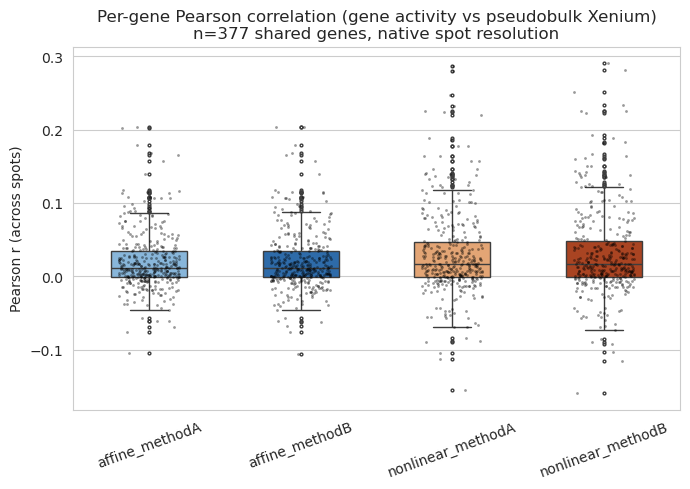

In [12]:
# Plot 1: per-gene Pearson correlation distribution, one box per condition (native resolution)
fig, ax = plt.subplots(figsize=(7, 5))
order = COND_ORDER
sns.boxplot(data=per_gene_long, x="condition", y="pearson", order=order, hue="condition", ax=ax,
            palette=COND_COLORS, width=0.5, fliersize=2, legend=False)
sns.stripplot(data=per_gene_long, x="condition", y="pearson", order=order, ax=ax,
              color="black", size=2, alpha=0.4, jitter=0.2)
ax.set_title(f"Per-gene Pearson correlation (gene activity vs pseudobulk Xenium)\n"
             f"n={len(shared_genes)} shared genes, native spot resolution")
ax.set_ylabel("Pearson r (across spots)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(os.path.join(outdir, "gene_loss_plot1_per_gene_pearson_boxplot_v2.png"), dpi=150)
plt.show()


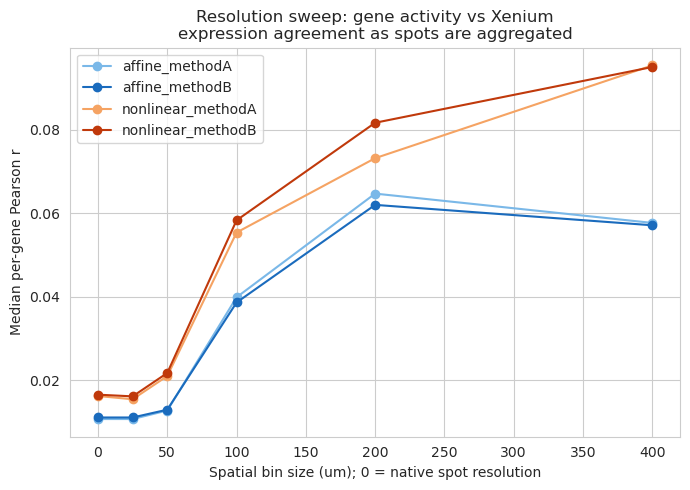

In [13]:
# Plot 2: resolution sweep -- median per-gene Pearson vs grid bin size, one line per condition
fig, ax = plt.subplots(figsize=(7, 5))
for name in order:
    sub = resolution_df[resolution_df["condition"] == name]
    ax.plot(sub["resolution_um"], sub["median_gene_pearson"], marker="o", color=COND_COLORS[name], label=name)
ax.set_xlabel("Spatial bin size (um); 0 = native spot resolution")
ax.set_ylabel("Median per-gene Pearson r")
ax.set_title("Resolution sweep: gene activity vs Xenium\nexpression agreement as spots are aggregated")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(outdir, "gene_loss_plot2_resolution_sweep_v2.png"), dpi=150)
plt.show()


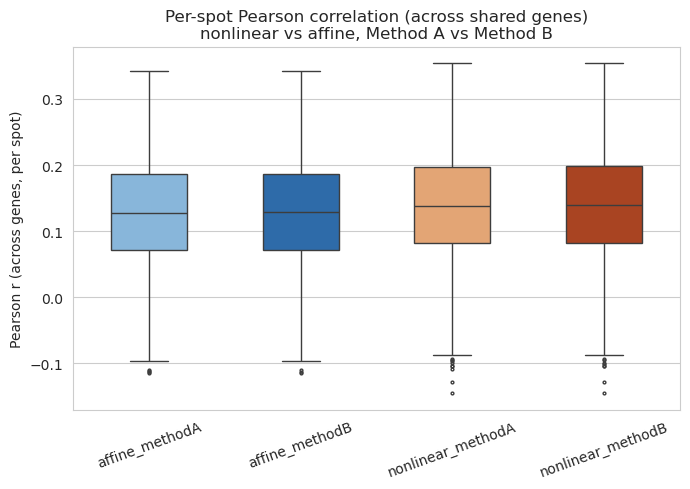

In [14]:
# Plot 3: per-spot Pearson correlation, affine vs nonlinear, faceted by assignment method
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=per_spot_long, x="condition", y="pearson", order=order, hue="condition", ax=ax,
            palette=COND_COLORS, width=0.5, fliersize=2, legend=False)
ax.set_title("Per-spot Pearson correlation (across shared genes)\nnonlinear vs affine, Method A vs Method B")
ax.set_ylabel("Pearson r (across genes, per spot)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(os.path.join(outdir, "gene_loss_plot3_per_spot_pearson_boxplot_v2.png"), dpi=150)
plt.show()


## 8b. Method B (Voronoi + soft filter) vs Method A (NN cutoff): head-to-head

Fixing alignment to nonlinear (the better alignment from above), directly compare the two
assignment methods on the *same* spots/genes: coverage (how many cells get used at all),
assignment precision (mean distance), and paired score differences (so ties where both
methods agree don't dilute the comparison).

In [15]:
def paired_method_comparison(name_a, name_b, mapping_files, gene_activity_by_idx, xenium_expr, shared_genes):
    raw_a = pd.read_csv(os.path.join(rcmp_dir, mapping_files[name_a][0]))
    raw_b = pd.read_csv(os.path.join(rcmp_dir, mapping_files[name_b][0]))

    coverage = pd.DataFrame({
        name_a: {
            "cells_kept": mappings[name_a].shape[0],
            "cells_total": raw_a.shape[0],
            "pct_cells_kept": 100 * mappings[name_a].shape[0] / raw_a.shape[0],
            "mean_cells_per_spot": mappings[name_a].groupby("atac_spot_idx").size().mean(),
            "mean_assign_dist_um": mappings[name_a]["distance_um"].mean(),
        },
        name_b: {
            "cells_kept": mappings[name_b].shape[0],
            "cells_total": raw_b.shape[0],
            "pct_cells_kept": 100 * mappings[name_b].shape[0] / raw_b.shape[0],
            "mean_cells_per_spot": mappings[name_b].groupby("atac_spot_idx").size().mean(),
            "mean_assign_dist_um": mappings[name_b]["distance_um"].mean(),
        },
    }).T
    return coverage

coverage_table = paired_method_comparison(
    "nonlinear_methodA", "nonlinear_methodB", mapping_files, gene_activity_by_idx, xenium_expr, shared_genes
)
coverage_table.round(2)


,cells_kept,cells_total,pct_cells_kept,mean_cells_per_spot,mean_assign_dist_um
nonlinear_methodA,55330.0,60593.0,91.31,4.83,12.14
nonlinear_methodB,60397.0,60593.0,99.68,5.27,12.99


In [16]:
# Paired per-gene and per-spot differences (Method B - Method A), nonlinear alignment fixed
pg_a = results["nonlinear_methodA"]["per_gene"].set_index("gene")
pg_b = results["nonlinear_methodB"]["per_gene"].set_index("gene")
paired_genes = pg_a[["pearson"]].join(pg_b[["pearson"]], lsuffix="_A", rsuffix="_B").dropna()
gene_diff = paired_genes["pearson_B"] - paired_genes["pearson_A"]

ps_a = results["nonlinear_methodA"]["per_spot"].set_index("atac_spot_idx")
ps_b = results["nonlinear_methodB"]["per_spot"].set_index("atac_spot_idx")
common_spots = ps_a.index.intersection(ps_b.index)
paired_spots = ps_a.loc[common_spots, ["pearson"]].join(
    ps_b.loc[common_spots, ["pearson"]], lsuffix="_A", rsuffix="_B"
)
spot_diff = paired_spots["pearson_B"] - paired_spots["pearson_A"]

from scipy.stats import wilcoxon
gene_stat, gene_p = wilcoxon(paired_genes["pearson_B"], paired_genes["pearson_A"])
spot_stat, spot_p = wilcoxon(paired_spots["pearson_B"], paired_spots["pearson_A"])

paired_summary = pd.DataFrame({
    "per_gene (n=377)": {
        "mean_diff_B_minus_A": gene_diff.mean(), "median_diff_B_minus_A": gene_diff.median(),
        "frac_B_better": (gene_diff > 0).mean(), "wilcoxon_p": gene_p,
    },
    "per_spot (n=%d)" % len(common_spots): {
        "mean_diff_B_minus_A": spot_diff.mean(), "median_diff_B_minus_A": spot_diff.median(),
        "frac_B_better": (spot_diff > 0).mean(), "wilcoxon_p": spot_p,
    },
}).T
paired_summary.round(4)


,mean_diff_B_minus_A,median_diff_B_minus_A,frac_B_better,wilcoxon_p
per_gene (n=377),0.0003,0.0004,0.5597,0.0491
per_spot (n=11162),0.0010,0.0000,0.1846,0.0000


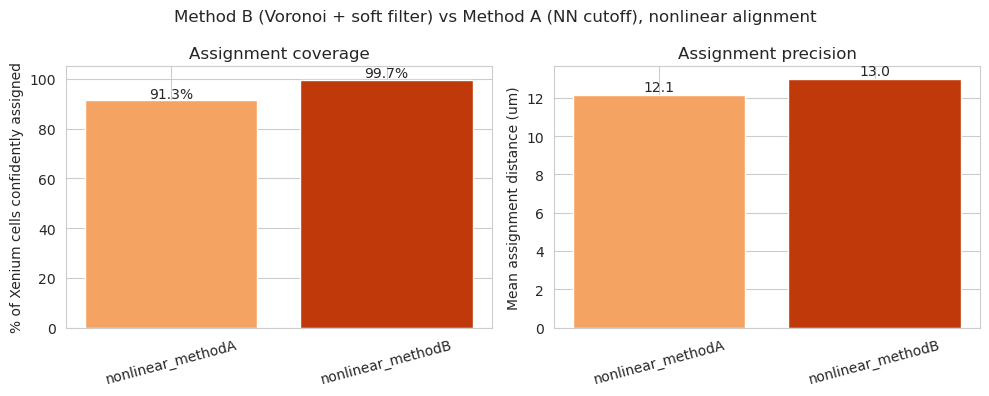

In [17]:
# Plot 4: cell coverage (% of cells confidently assigned) -- shows Method B keeps far more cells
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(coverage_table.index, coverage_table["pct_cells_kept"], color=[COND_COLORS["nonlinear_methodA"], COND_COLORS["nonlinear_methodB"]])
axes[0].set_ylabel("% of Xenium cells confidently assigned")
axes[0].set_title("Assignment coverage")
axes[0].set_ylim(0, 105)
for i, v in enumerate(coverage_table["pct_cells_kept"]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center")

axes[1].bar(coverage_table.index, coverage_table["mean_assign_dist_um"], color=[COND_COLORS["nonlinear_methodA"], COND_COLORS["nonlinear_methodB"]])
axes[1].set_ylabel("Mean assignment distance (um)")
axes[1].set_title("Assignment precision")
for i, v in enumerate(coverage_table["mean_assign_dist_um"]):
    axes[1].text(i, v + 0.2, f"{v:.1f}", ha="center")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Method B (Voronoi + soft filter) vs Method A (NN cutoff), nonlinear alignment")
fig.tight_layout()
fig.savefig(os.path.join(outdir, "gene_loss_plot4_coverage_precision_v2.png"), dpi=150)
plt.show()


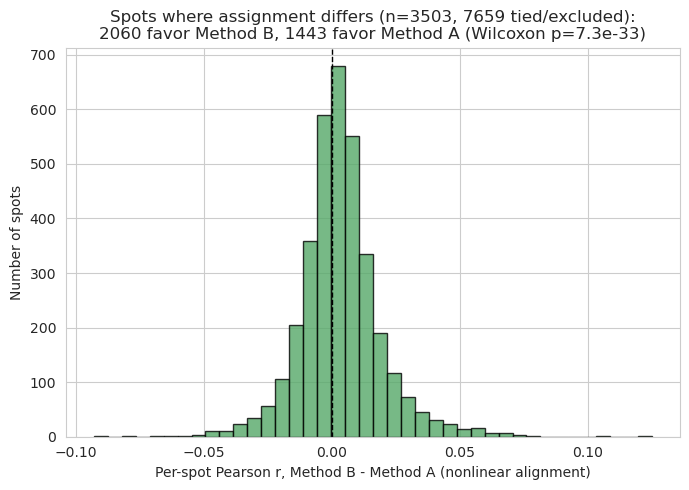

In [18]:
# Plot 5: paired per-spot score difference (Method B - Method A) -- most spots tie (same cells
# assigned by both methods), but among spots where the methods disagree, B skews positive.
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(spot_diff[spot_diff != 0], bins=40, color="#55A868", edgecolor="black", alpha=0.8)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Per-spot Pearson r, Method B - Method A (nonlinear alignment)")
ax.set_ylabel("Number of spots")
n_tied = (spot_diff == 0).sum()
n_pos = (spot_diff > 0).sum()
n_neg = (spot_diff < 0).sum()
ax.set_title(
    f"Spots where assignment differs (n={n_pos + n_neg}, {n_tied} tied/excluded):\n"
    f"{n_pos} favor Method B, {n_neg} favor Method A (Wilcoxon p={spot_p:.1e})"
)
fig.tight_layout()
fig.savefig(os.path.join(outdir, "gene_loss_plot5_methodB_vs_A_paired_diff_v2.png"), dpi=150)
plt.show()


## 9. Summary

In [19]:
print("Summary score per condition (native resolution):")
print(summary_table[["n_spots", "median_gene_pearson", "median_gene_spearman", "global_pearson"]])

best = summary_table["median_gene_pearson"].astype(float).idxmax()
print(f"\nBest condition by median per-gene Pearson: {best}")


Summary score per condition (native resolution):
                   n_spots  median_gene_pearson  median_gene_spearman  \
condition                                                               
affine_methodA     11030.0             0.010722              0.011962   
affine_methodB     11033.0             0.011094              0.011761   
nonlinear_methodA  11162.0             0.016238              0.016488   
nonlinear_methodB  11181.0             0.016559              0.016338   

                   global_pearson  
condition                          
affine_methodA           0.129128  
affine_methodB           0.129291  
nonlinear_methodA        0.137931  
nonlinear_methodB        0.138891  

Best condition by median per-gene Pearson: nonlinear_methodB
